In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
sns.set_theme()
sns.set_style("whitegrid", {'grid.color': 'black', 'axes.edgecolor': 'black', 'axes.axisbelow': 'line'})
sns.set_style({'font.family': 'serif'})
sns.set_style({'font.serif': ["Linux Libertine O"]})

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Linux Libertine O"],
    "axes.unicode_minus": False,
})

In [3]:
p = './data/pipeline_outputs/evaluation_results_by_experiment.csv'
df_all_exp = pd.read_csv(p)

In [4]:
def get_interface_group(exp_id):
        if "-e2_upstream-" in exp_id:
            return "e2_upstream"
        elif "-a1_downstream-" in exp_id:
            return "a1_downstream"
        elif "-f1-u_dl-" in exp_id:
            return "f1-u_dl"
        elif "-f1-c_dl-" in exp_id:
            return "f1-c_dl"
        else:
            return "other"
        
def get_experiment_type(exp_id):
        if "pkt_loss" in exp_id:
            return "pkt_loss"
        elif "pkt_delay" in exp_id:
            return "pkt_delay"
        else:
            return "other"
        
def get_experiment_strength(exp_id):
        if "_low-" in exp_id:
            return "low"
        elif "_medium-" in exp_id:
            return "medium"
        elif "_high-" in exp_id:
            return "high"
        elif "_100-" in exp_id:
            return "100"
        else:
            return "other"

def get_iteration(exp_id):
        return exp_id.split('-itr_')[1]
        
df_all_exp['interface'] = df_all_exp['experiment_id'].apply(get_interface_group)
df_all_exp['experiment_type'] = df_all_exp['experiment_id'].apply(get_experiment_type)
df_all_exp['experiment_strength'] = df_all_exp['experiment_id'].apply(get_experiment_strength)
df_all_exp['iteration'] = df_all_exp['experiment_id'].apply(get_iteration)
df_all_exp

,experiment_id,anomaly_type_cls,anomaly_location_cls,t_cls_accuracy,t_cls_f1_score_micro,t_cls_f1_score_macro,l_cls_accuracy,l_cls_f1_score_micro,l_cls_f1_score_macro,fr_bleu_score,...,fr_bert_score_F1,fr_bert_score_P,fr_bert_score_R,fr_rouge_score_F1,fr_rouge_score_P,fr_rouge_score_R,interface,experiment_type,experiment_strength,iteration
0,pkt_loss_100-f1-c_dl-itr_4,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.291126,...,0.548099,0.538300,0.556456,0.454545,0.460526,0.448718,f1-c_dl,pkt_loss,100,4
1,pkt_loss_medium-f1-u_dl-itr_1,Network Packet Loss,F1-u interface,1.0,1.0,1.0,1.0,1.0,1.0,0.003461,...,-0.063158,-0.022939,-0.106124,0.087719,0.119760,0.069204,f1-u_dl,pkt_loss,medium,1
2,pkt_loss_high-f1-c_dl-itr_2,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.239624,...,0.605085,0.589454,0.619511,0.429043,0.442177,0.416667,f1-c_dl,pkt_loss,high,2
3,pkt_loss_low-a1_downstream-itr_2,Network Packet Loss,A1 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.267445,...,0.599392,0.601765,0.595719,0.404011,0.407514,0.400568,a1_downstream,pkt_loss,low,2
4,pkt_delay_low-e2_upstream-itr_5,Network Latency,E2 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.006099,...,-0.090473,-0.044335,-0.139226,0.132890,0.133333,0.132450,e2_upstream,pkt_delay,low,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,pkt_delay_low-a1_downstream-itr_1,Network Latency,A1 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.196414,...,0.394473,0.453882,0.334437,0.330303,0.344937,0.316860,a1_downstream,pkt_delay,low,1
125,pkt_loss_medium-f1-c_dl-itr_2,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.217041,...,0.360066,0.377776,0.340407,0.345515,0.358621,0.333333,f1-c_dl,pkt_loss,medium,2
126,pkt_loss_low-f1-u_dl-itr_5,Network Packet Loss,F1-u interface,1.0,1.0,1.0,1.0,1.0,1.0,0.169215,...,0.559334,0.561146,0.556090,0.363057,0.336283,0.394464,f1-u_dl,pkt_loss,low,5
127,pkt_delay_high-a1_downstream-itr_1,Network Latency,A1 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.846223,...,0.741583,0.768519,0.714069,0.919668,0.878307,0.965116,a1_downstream,pkt_delay,high,1


In [5]:
# remove experiments used for groundtruth generation

df_all_exp = df_all_exp[~((df_all_exp['experiment_type'] == 'pkt_loss') & (df_all_exp['experiment_strength'] == 'high') & (df_all_exp['iteration'] == '1'))]
df_all_exp = df_all_exp[~((df_all_exp['experiment_type'] == 'pkt_delay') & (df_all_exp['experiment_strength'] == 'high') & (df_all_exp['iteration'] == '1'))]
df_all_exp

,experiment_id,anomaly_type_cls,anomaly_location_cls,t_cls_accuracy,t_cls_f1_score_micro,t_cls_f1_score_macro,l_cls_accuracy,l_cls_f1_score_micro,l_cls_f1_score_macro,fr_bleu_score,...,fr_bert_score_F1,fr_bert_score_P,fr_bert_score_R,fr_rouge_score_F1,fr_rouge_score_P,fr_rouge_score_R,interface,experiment_type,experiment_strength,iteration
0,pkt_loss_100-f1-c_dl-itr_4,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.291126,...,0.548099,0.538300,0.556456,0.454545,0.460526,0.448718,f1-c_dl,pkt_loss,100,4
1,pkt_loss_medium-f1-u_dl-itr_1,Network Packet Loss,F1-u interface,1.0,1.0,1.0,1.0,1.0,1.0,0.003461,...,-0.063158,-0.022939,-0.106124,0.087719,0.119760,0.069204,f1-u_dl,pkt_loss,medium,1
2,pkt_loss_high-f1-c_dl-itr_2,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.239624,...,0.605085,0.589454,0.619511,0.429043,0.442177,0.416667,f1-c_dl,pkt_loss,high,2
3,pkt_loss_low-a1_downstream-itr_2,Network Packet Loss,A1 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.267445,...,0.599392,0.601765,0.595719,0.404011,0.407514,0.400568,a1_downstream,pkt_loss,low,2
4,pkt_delay_low-e2_upstream-itr_5,Network Latency,E2 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.006099,...,-0.090473,-0.044335,-0.139226,0.132890,0.133333,0.132450,e2_upstream,pkt_delay,low,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,pkt_loss_low-f1-c_dl-itr_3,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.200142,...,0.457049,0.462865,0.449482,0.378855,0.349593,0.413462,f1-c_dl,pkt_loss,low,3
124,pkt_delay_low-a1_downstream-itr_1,Network Latency,A1 interface,1.0,1.0,1.0,1.0,1.0,1.0,0.196414,...,0.394473,0.453882,0.334437,0.330303,0.344937,0.316860,a1_downstream,pkt_delay,low,1
125,pkt_loss_medium-f1-c_dl-itr_2,Network Packet Loss,F1-c interface,1.0,1.0,1.0,1.0,1.0,1.0,0.217041,...,0.360066,0.377776,0.340407,0.345515,0.358621,0.333333,f1-c_dl,pkt_loss,medium,2
126,pkt_loss_low-f1-u_dl-itr_5,Network Packet Loss,F1-u interface,1.0,1.0,1.0,1.0,1.0,1.0,0.169215,...,0.559334,0.561146,0.556090,0.363057,0.336283,0.394464,f1-u_dl,pkt_loss,low,5


In [6]:
columns_to_aggregate = df_all_exp.columns.difference(['interface', 'experiment_type', 'experiment_strength', 'iteration','experiment_id', 'anomaly_type_cls', 'anomaly_location_cls'])
grouped_df = df_all_exp.groupby(['interface', 'experiment_type', 'experiment_strength'])[columns_to_aggregate].mean()
grouped_df

fr_bert_score_F1  \
interface     experiment_type experiment_strength                     
a1_downstream pkt_delay       high                         0.443497   
                              low                          0.379595   
                              medium                       0.396553   
              pkt_loss        100                          0.472134   
                              high                         0.183673   
                              low                          0.556941   
                              medium                       0.469816   
e2_upstream   pkt_delay       high                         0.478144   
                              low                          0.235321   
                              medium                       0.186276   
              pkt_loss        100                          0.385769   
                              high                         0.497113   
                              low                          0.386493   
                              medium                       0.306524   
f1-c_dl       pkt_delay       low                          0.088796   
                              medium                       0.198056   
              pkt_loss        100                          0.499277   
                              high                         0.576299   
                              low                          0.446119   
                              medium                       0.410860   
f1-u_dl       pkt_delay       high                         0.571828   
                              low                          0.051690   
                              medium                       0.322222   
              pkt_loss        100                          0.127395   
                              high                         0.368931   
                              low                          0.512491   
                              medium                       0.198140   

                                                   fr_bert_score_P  \
interface     experiment_type experiment_strength                    
a1_downstream pkt_delay       high                        0.470482   
                              low                         0.431324   
                              medium                      0.430303   
              pkt_loss        100                         0.456359   
                              high                        0.196088   
                              low                         0.559069   
                              medium                      0.466620   
e2_upstream   pkt_delay       high                        0.462602   
                              low                         0.236782   
                              medium                      0.245347   
              pkt_loss        100                         0.374409   
                              high                        0.493233   
                              low                         0.387056   
                              medium                      0.314510   
f1-c_dl       pkt_delay       low                         0.074722   
                              medium                      0.134408   
              pkt_loss        100                         0.485892   
                              high                        0.567356   
                              low                         0.440014   
                              medium                      0.411312   
f1-u_dl       pkt_delay       high                        0.575749   
                              low                         0.149473   
                              medium                      0.345296   
              pkt_loss        100                         0.149766   
                              high                        0.379068   
                              low                         0.517853   
                              m

In [7]:
metric_columns = [
    't_cls_accuracy', 't_cls_f1_score_micro', 't_cls_f1_score_macro',
    'l_cls_accuracy', 'l_cls_f1_score_micro', 'l_cls_f1_score_macro',
    'fr_bleu_score', 'fr_meteor_score', 'fr_bert_score_F1', 'fr_bert_score_P', 'fr_bert_score_R', 'fr_rouge_score_F1', 'fr_rouge_score_P', 'fr_rouge_score_R'
    ]

df_all_exp['experiment_prefix'] = df_all_exp['experiment_id'].apply(lambda x: x.split('-itr_')[0])
df_by_experiment = df_all_exp.groupby('experiment_prefix')[metric_columns].mean().reset_index()

In [8]:
classification_metrics = ['t_cls_accuracy', 'l_cls_accuracy']
df_by_experiment = df_all_exp.groupby('interface')[classification_metrics].mean()

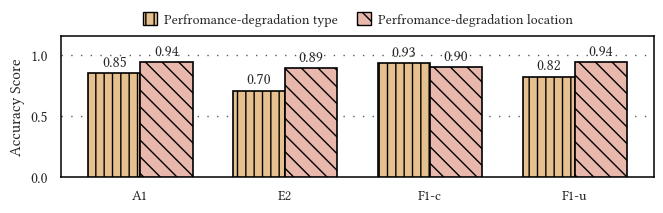

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

interfaces_label_map = {
    'a1_downstream': 'A1',
    'e2_upstream': 'E2',
    'f1-c_dl': 'F1-c',
    'f1-u_dl': 'F1-u'
}

column_map = {
    't_cls_accuracy': 'Perfromance-degradation type',
    'l_cls_accuracy': 'Perfromance-degradation location'
}
metrics = list(column_map.keys())
metric_labels = [column_map[m] for m in metrics]

labels = [interfaces_label_map.get(i, i) for i in df_by_experiment.index]
x = np.arange(len(labels))
width = 0.36

bar_colors = ['#e6c08f', '#e8b8ad']
bar_hatches = ['||', '\\\\']

fig, ax = plt.subplots(figsize=(6.8, 2.4))
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#ffffff")

for i, metric in enumerate(metrics):
    offset = (i - len(metrics) / 2) * width + width / 2
    bars = ax.bar(
        x + offset,
        df_by_experiment[metric],
        width,
        label=metric_labels[i],
        color=bar_colors[i % len(bar_colors)],
        edgecolor='black',
        linewidth=1.2,
        hatch=bar_hatches[i % len(bar_hatches)],
        zorder=5,
    )
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=11)

ax.set_ylabel('Accuracy Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=10)
ax.set_ylim(0, 1.15)


ax.grid(axis='y', linestyle=(0, (1, 6)), color='black', alpha=0.65, linewidth=1, zorder=0)
ax.grid(axis='x', visible=False)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.1)

legend_handles = [
    Patch(facecolor=bar_colors[i], edgecolor='black', hatch=bar_hatches[i], label=metric_labels[i])
    for i in range(len(metrics))
]
leg = ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.5, 1.24),
    loc='upper center',
    ncol=len(metrics),
    frameon=False,
    fontsize=10,
    handlelength=1.0,
    handletextpad=0.5,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.2,
    fancybox=False,
    shadow=False,
    markerfirst=True,
    handleheight=1.0,
    alignment='center',
)

plt.tight_layout()
plt.savefig('./plot_outputs/experiment_accuracy_plot_newstyle_libertine.pdf', dpi=300, bbox_inches='tight')
plt.show()

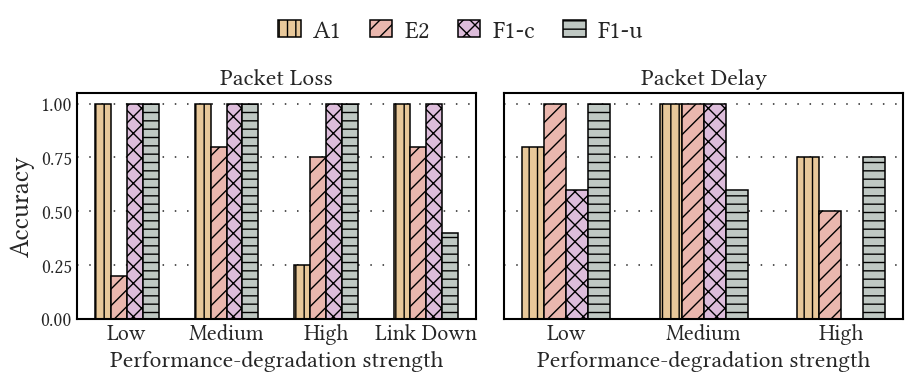

In [10]:
cls_eval_df = df_all_exp.groupby(['interface', 'experiment_type', 'experiment_strength'])[classification_metrics].mean()

anomaly_strengths_loss = ['low', 'medium', 'high', '100']
interfaces = ['a1_downstream', 'e2_upstream', 'f1-c_dl', 'f1-u_dl']
anomaly_strengths_delay = ['low', 'medium', 'high']

anomaly_strengths_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
    '100': 'Link Down'
}

anomaly_strengths_delay_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
}
anomaly_strengths_labels = [anomaly_strengths_label_map.get(s, s) for s in anomaly_strengths_loss]
anomaly_strengths_delay_labels = [anomaly_strengths_delay_label_map.get(s, s) for s in anomaly_strengths_delay]

legend_labels = [interfaces_label_map[interface] for interface in interfaces]

n_bars = len(interfaces)
bar_width = 0.16
offsets = np.arange(n_bars) - (n_bars - 1) / 2
offsets = offsets * bar_width

panel_gray = "#FFFFFF"
series_colors = ['#E8C89A', '#EAB7AE', '#DDBDDB', '#BFC8C3']
series_hatches = ['||', '//', 'xx', '--']

def style_axes_like_reference(ax):
    ax.set_facecolor(panel_gray)
    ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig2, axs2 = plt.subplots(1, 2, figsize=(9.2, 3.7), sharey=True)
fig2.patch.set_facecolor(panel_gray)

x_indices_loss = np.arange(len(anomaly_strengths_loss))
for i, interface in enumerate(interfaces):
    vals = []
    for s in anomaly_strengths_loss:
        try:
            vals.append(cls_eval_df.loc[(interface, 'pkt_loss', s)]['t_cls_accuracy'])
        except KeyError:
            vals.append(np.nan)
    x_pos = x_indices_loss + offsets[i]
    axs2[0].bar(
        x_pos, vals, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

x_indices_delay = np.arange(len(anomaly_strengths_delay))
for i, interface in enumerate(interfaces):
    vals = []
    for s in anomaly_strengths_delay:
        try:
            vals.append(cls_eval_df.loc[(interface, 'pkt_delay', s)]['t_cls_accuracy'])
        except KeyError:
            vals.append(np.nan)
    x_pos = x_indices_delay + offsets[i]
    axs2[1].bar(
        x_pos, vals, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

style_axes_like_reference(axs2[0])
style_axes_like_reference(axs2[1])

axs2[0].set_title('Packet Loss', fontsize=17)
axs2[0].set_xlabel('Performance-degradation strength', fontsize=17)
axs2[0].set_ylabel('Accuracy', fontsize=19)
axs2[0].set_xticks(x_indices_loss)
axs2[0].set_xticklabels(anomaly_strengths_labels, fontsize=16)

axs2[1].set_title('Packet Delay', fontsize=17)
axs2[1].set_xlabel('Performance-degradation strength', fontsize=17)
axs2[1].set_xticks(x_indices_delay)
axs2[1].set_xticklabels(anomaly_strengths_delay_labels, fontsize=16)

handles, labels = axs2[0].get_legend_handles_labels()
fig2.legend(
    handles, labels, loc='upper center', ncol=len(interfaces),
    bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=18,
    handlelength=0.9, handletextpad=0.5, columnspacing=1.1
)

plt.tight_layout()
plt.subplots_adjust(top=0.80)
plt.savefig('./plot_outputs/anomaly_type_vs_strength_newstyle_libertine.pdf', bbox_inches='tight')
plt.show()

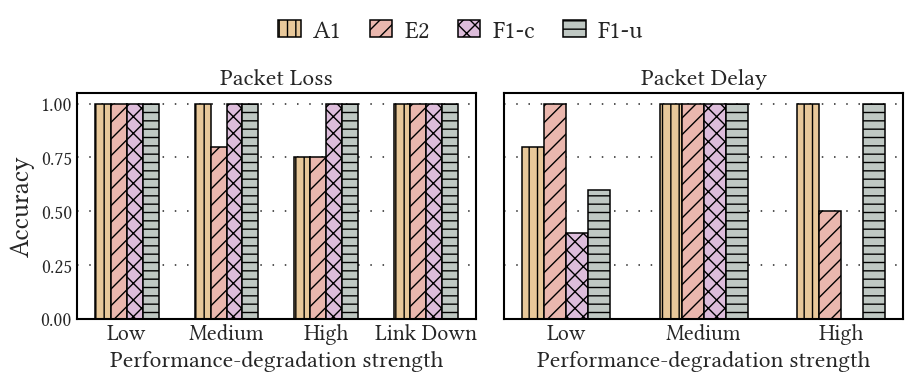

In [11]:
cls_eval_df = df_all_exp.groupby(['interface', 'experiment_type', 'experiment_strength'])[classification_metrics].mean()

anomaly_strengths_loss = ['low', 'medium', 'high', '100']
interfaces = ['a1_downstream', 'e2_upstream', 'f1-c_dl', 'f1-u_dl']
anomaly_strengths_delay = ['low', 'medium', 'high']

anomaly_strengths_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
    '100': 'Link Down'
}

anomaly_strengths_delay_label_map = {
    'low': 'Low',
    'medium': 'Medium',
    'high': 'High',
}
anomaly_strengths_labels = [anomaly_strengths_label_map.get(s, s) for s in anomaly_strengths_loss]
anomaly_strengths_delay_labels = [anomaly_strengths_delay_label_map.get(s, s) for s in anomaly_strengths_delay]

legend_labels = [interfaces_label_map[interface] for interface in interfaces]

n_bars = len(interfaces)
bar_width = 0.16
offsets = np.arange(n_bars) - (n_bars - 1) / 2
offsets = offsets * bar_width

panel_gray = "#FFFFFF"
series_colors = ['#E8C89A', '#EAB7AE', '#DDBDDB', '#BFC8C3']
series_hatches = ['||', '//', 'xx', '--']

def style_axes_like_reference(ax):
    ax.set_facecolor(panel_gray)
    ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=14)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig2, axs2 = plt.subplots(1, 2, figsize=(9.2, 3.7), sharey=True)
fig2.patch.set_facecolor(panel_gray)

x_indices_loss = np.arange(len(anomaly_strengths_loss))
for i, interface in enumerate(interfaces):
    vals = []
    for s in anomaly_strengths_loss:
        try:
            vals.append(cls_eval_df.loc[(interface, 'pkt_loss', s)]['l_cls_accuracy'])
        except KeyError:
            vals.append(np.nan)
    x_pos = x_indices_loss + offsets[i]
    axs2[0].bar(
        x_pos, vals, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

x_indices_delay = np.arange(len(anomaly_strengths_delay))
for i, interface in enumerate(interfaces):
    vals = []
    for s in anomaly_strengths_delay:
        try:
            vals.append(cls_eval_df.loc[(interface, 'pkt_delay', s)]['l_cls_accuracy'])
        except KeyError:
            vals.append(np.nan)
    x_pos = x_indices_delay + offsets[i]
    axs2[1].bar(
        x_pos, vals, width=bar_width, label=legend_labels[i],
        color=series_colors[i], edgecolor='black', linewidth=1.1,
        hatch=series_hatches[i], alpha=1.0, zorder=2
    )

style_axes_like_reference(axs2[0])
style_axes_like_reference(axs2[1])

axs2[0].set_title('Packet Loss', fontsize=17)
axs2[0].set_xlabel('Performance-degradation strength', fontsize=17)
axs2[0].set_ylabel('Accuracy', fontsize=19)
axs2[0].set_xticks(x_indices_loss)
axs2[0].set_xticklabels(anomaly_strengths_labels, fontsize=16)

axs2[1].set_title('Packet Delay', fontsize=17)
axs2[1].set_xlabel('Performance-degradation strength', fontsize=17)
axs2[1].set_xticks(x_indices_delay)
axs2[1].set_xticklabels(anomaly_strengths_delay_labels, fontsize=16)

handles, labels = axs2[0].get_legend_handles_labels()
fig2.legend(
    handles, labels, loc='upper center', ncol=len(interfaces),
    bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=18,
    handlelength=0.9, handletextpad=0.5, columnspacing=1.1
)

plt.tight_layout()
plt.subplots_adjust(top=0.80)
plt.savefig('./plot_outputs/anomaly_location_vs_strength_newstyle_libertine.pdf', bbox_inches='tight')
plt.show()

In [12]:


df_all_exp['interface_group'] = df_all_exp['experiment_id'].apply(get_interface_group)

metrics = [
    'fr_bleu_score',
    'fr_meteor_score',
    'fr_bert_score_F1',
    'fr_bert_score_P',
    'fr_bert_score_R',
    'fr_rouge_score_F1',
    'fr_rouge_score_P',
    'fr_rouge_score_R'
]

metrics_map = {
    'fr_bleu_score' : r'BLEU',
    'fr_meteor_score': r'METEOR',
    #'fr_rouge_score_P' : r'$ROUGE$-P',
    'fr_rouge_score_R' : r'ROUGE-R',
    #'fr_rouge_score_F1' : r'$ROUGE$-F1',
    #'fr_bert_score_P' : r'$B\sc{ERT}S-P$',
    'fr_bert_score_R' : r'BERT-R',
    #'fr_bert_score_F1': 'B\sc{ERT}S-F1',
}

interface_name_map = {
    'f1-c_dl': 'F1-c',
    'f1-u_dl': 'F1-u',
    'e2_upstream': 'E2',
    'a1_downstream': 'A1'
}

df_all_exp['interface_group'] = df_all_exp['interface_group'].map(interface_name_map)
df_pkt_loss = df_all_exp[df_all_exp['experiment_type'] == 'pkt_loss']
df_pkt_delay = df_all_exp[df_all_exp['experiment_type'] == 'pkt_delay']
metrics_keys = list(metrics_map.keys())


df_melted = df_all_exp.melt(id_vars=['interface_group'], value_vars=metrics_keys, var_name='Metric', value_name='Score')
df_melted_loss = df_pkt_loss.melt(id_vars=['interface_group'], value_vars=metrics_keys, var_name='Metric', value_name='Score')
df_melted_delay = df_pkt_delay.melt(id_vars=['interface_group'], value_vars=metrics_keys, var_name='Metric', value_name='Score')


df_melted['Metric'] = df_melted['Metric'].map(metrics_map)
df_melted_loss['Metric'] = df_melted_loss['Metric'].map(metrics_map)
df_melted_delay['Metric'] = df_melted_delay['Metric'].map(metrics_map)

/tmp/ipykernel_2148961/430304634.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)


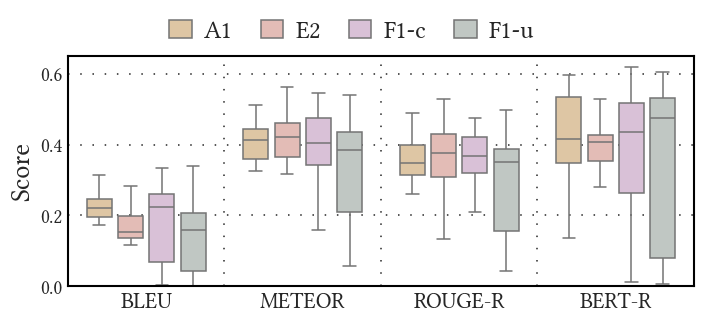

In [13]:
fig = plt.figure(figsize=(7.2, 3.7))
ax = plt.gca()

panel_gray = "#FFFFFF"
series_colors = ['#E8C89A', '#EAB7AE', '#DDBDDB', '#BFC8C3']
ax.set_facecolor(panel_gray)
df_melted['Score'] = df_melted['Score'].abs()

sns.boxplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='interface_group',
    fliersize=0,
    hue_order=['A1', 'E2', 'F1-c', 'F1-u'],
    gap=0.2,
    palette=series_colors,
    linewidth=1.1,
    ax=ax,
    zorder=2,
 )

for i in range(len(df_melted['Metric'].unique()) - 1):
    ax.axvline(x=i + 0.5, color='black', linestyle=(0, (1, 7)), alpha=0.85, linewidth=1.1, zorder=1)

ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=14)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.set_ylabel('Score', fontsize=19)
ax.set_xlabel(None)

ymin = max(df_melted['Score'].min() - 0.03, 0.0)
ymax = df_melted['Score'].max() + 0.03
ax.set_ylim([ymin, ymax])
ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)

handles, labels = ax.get_legend_handles_labels()
if ax.get_legend() is not None:
    ax.get_legend().remove()

fig.legend(
    handles, labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.9),
    frameon=False,
    fontsize=18,
    handlelength=0.9,
    handletextpad=0.5,
    columnspacing=1.1,
 )

plt.tight_layout()
plt.subplots_adjust(top=0.74)
plt.savefig('./plot_outputs/final_report_boxplot_newstyle.pdf', bbox_inches='tight')
plt.show()

## Confusion matrices

In [14]:


experiment_type_map = {
    'pkt_loss': 'Loss',
    'pkt_delay': 'Delay'
}
interface_name_map = {
    'f1-c_dl': 'F1-c',
    'f1-u_dl': 'F1-u',
    'e2_upstream': 'E2',
    'a1_downstream': 'A1'
}

anomaly_type_cls_map = {
    'Network Packet Loss': 'Loss',
    'Network Latency': 'Delay'
}

anomaly_location_cls_map = {
    'A1 interface': 'A1',
    'E2 interface': 'E2',
    'F1-c interface': 'F1-c',
    'F1-u interface': 'F1-u'
}


df_all_exp['experiment_type'] = df_all_exp['experiment_type'].map(experiment_type_map)
df_all_exp['interface'] = df_all_exp['interface'].map(interface_name_map)
df_all_exp['anomaly_type_cls'] = df_all_exp['anomaly_type_cls'].map(anomaly_type_cls_map)
df_all_exp['anomaly_location_cls'] = df_all_exp['anomaly_location_cls'].map(anomaly_location_cls_map)



exeriment_type_gt = df_all_exp['experiment_type']
location_gt = df_all_exp['interface']

exeriment_type_pred = df_all_exp['anomaly_type_cls']
location_pred = df_all_exp['anomaly_location_cls']

mask_type = exeriment_type_gt.notna() & exeriment_type_pred.notna()
gt_type = exeriment_type_gt[mask_type]
pred_type = exeriment_type_pred[mask_type]

mask_loc = location_gt.notna() & location_pred.notna()
gt_loc = location_gt[mask_loc]
pred_loc = location_pred[mask_loc]

type_labels = sorted(set(gt_type.unique()) | set(pred_type.unique()))
loc_labels = sorted(set(gt_loc.unique()) | set(pred_loc.unique()))

cm_type = confusion_matrix(gt_type, pred_type, labels=type_labels, normalize='true')
cm_loc = confusion_matrix(gt_loc, pred_loc, labels=loc_labels, normalize='true')




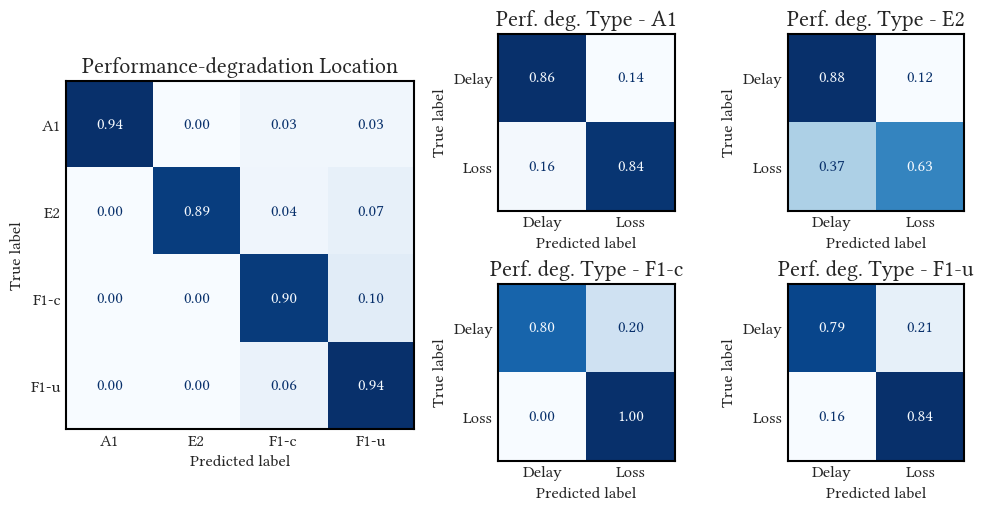

In [15]:
gt_type_a1 = gt_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'A1'].index)]
pred_type_a1 = pred_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'A1'].index)]
cm_type_a1 = confusion_matrix(gt_type_a1, pred_type_a1, labels=type_labels, normalize='true')

gt_type_e2 = gt_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'E2'].index)]
pred_type_e2 = pred_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'E2'].index)]
cm_type_e2 = confusion_matrix(gt_type_e2, pred_type_e2, labels=type_labels, normalize='true')

gt_type_f1c = gt_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'F1-c'].index)]
pred_type_f1c = pred_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'F1-c'].index)]
cm_type_f1c = confusion_matrix(gt_type_f1c, pred_type_f1c, labels=type_labels, normalize='true')

gt_type_f1u = gt_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'F1-u'].index)]
pred_type_f1u = pred_type[gt_type.index.isin(df_all_exp[df_all_exp['interface'] == 'F1-u'].index)]
cm_type_f1u = confusion_matrix(gt_type_f1u, pred_type_f1u, labels=type_labels, normalize='true')


panel_gray = "#FFFFFF"

def style_axes_like_reference(ax):
    ax.set_facecolor(panel_gray)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=12)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig = plt.figure(figsize=(10, 5), layout='constrained')
fig.patch.set_facecolor(panel_gray)


subfigs = fig.subfigures(1, 2, width_ratios=[1, 1.4])

ax_left = subfigs[0].subplots(1, 1)

ConfusionMatrixDisplay(cm_loc, display_labels=loc_labels).plot(
    ax=ax_left, cmap='Blues', values_format='.2f', colorbar=False
)
ax_left.set_title('Performance-degradation Location', fontsize=16)
style_axes_like_reference(ax_left)

axes_right = subfigs[1].subplots(2, 2)

ConfusionMatrixDisplay(cm_type_a1, display_labels=type_labels).plot(
    ax=axes_right[0, 0], cmap='Blues', values_format='.2f', colorbar=False
)
axes_right[0, 0].set_title('Perf. deg. Type - A1', fontsize=16)
style_axes_like_reference(axes_right[0, 0])

ConfusionMatrixDisplay(cm_type_e2, display_labels=type_labels).plot(
    ax=axes_right[0, 1], cmap='Blues', values_format='.2f', colorbar=False
)
axes_right[0, 1].set_title('Perf. deg. Type - E2', fontsize=16)
style_axes_like_reference(axes_right[0, 1])

ConfusionMatrixDisplay(cm_type_f1c, display_labels=type_labels).plot(
    ax=axes_right[1, 0], cmap='Blues', values_format='.2f', colorbar=False
)
axes_right[1, 0].set_title('Perf. deg. Type - F1-c', fontsize=16)
style_axes_like_reference(axes_right[1, 0])

ConfusionMatrixDisplay(cm_type_f1u, display_labels=type_labels).plot(
    ax=axes_right[1, 1], cmap='Blues', values_format='.2f', colorbar=False
)
axes_right[1, 1].set_title('Perf. deg. Type - F1-u', fontsize=16)
style_axes_like_reference(axes_right[1, 1])

plt.savefig('./plot_outputs/combined_confusion_matrices.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Execution time

In [16]:
import glob

            
pattern = "./data/pipeline_outputs/pkt_*/exec_time.txt"
file_paths = glob.glob(pattern)
exec_times_gpu = []
for file in file_paths:
    with open(file, 'r') as f:
        time_str = f.read().strip()
        try:
            exec_time = float(time_str)
            exec_times_gpu.append(exec_time)
        except ValueError:
            print(f"Could not convert to float: {time_str} in file {file}")

In [17]:

exec_times_all = pd.DataFrame({'GPU':exec_times_gpu})
exec_times_all

,GPU
0,548.587599
1,886.593400
2,625.411185
3,554.038600
4,992.123563
...,...
129,649.257389
130,779.494852
131,587.320323
132,598.311823


In [18]:
exec_times_all.median()

GPU    678.344729
dtype: float64

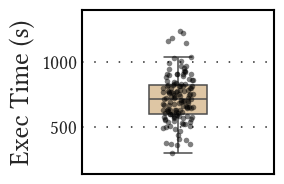

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



fig = plt.figure(figsize=(3, 2))
ax = plt.gca()

panel_gray = "#FFFFFF"
ax.set_facecolor(panel_gray)

gpu_data = exec_times_all[['GPU']]

sns.boxplot(
    data=gpu_data, 
    fliersize=0, 
    width=0.3,  
    color='#E8C89A',  
    linewidth=1.1,
    ax=ax,
    zorder=2
)

sns.stripplot(
    data=gpu_data,
    color='black',
    alpha=0.5, 
    size=4,
    jitter=0.08, 
    ax=ax,
    zorder=3
)

ax.set_yscale('log')
ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.set_ylabel('Exec Time (s)', fontsize=19)
ax.set_xlabel(None)

gpu_min = gpu_data.min().values[0]
gpu_max = gpu_data.max().values[0]
ymin = max(gpu_min * 0.8, 1e-3)
ymax = gpu_max * 1.25 
ax.set_ylim([ymin, ymax])

lo = int(np.floor(np.log10(ymin)))
hi = int(np.ceil(np.log10(ymax)))
ticks = []
for e in range(lo, hi + 1):
    for m in (1, 2, 5):
        t = m * (10 ** e)
        if ymin <= t <= ymax:
            ticks.append(t)
ticks = sorted(set(ticks))

ax.set_yticks(ticks)
ax.set_yticklabels([str(int(t)) for t in ticks])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xticks([])

plt.tight_layout()
plt.savefig('./plot_outputs/execution_time_boxplot_gpu_libertine.pdf')
plt.show()

# Graph soft-promting plot

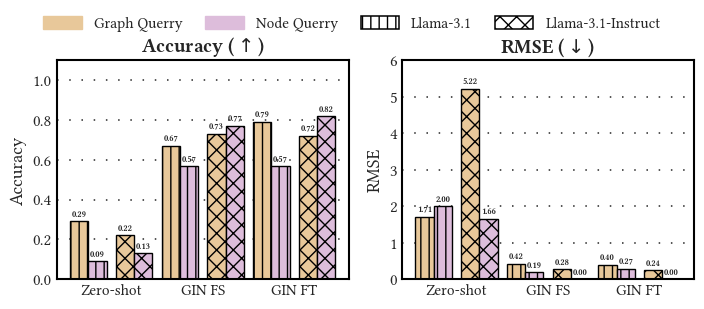

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

methods = ['Zero-shot', 'GIN FS', 'GIN FT']
x_indices = np.arange(len(methods))

# Data colledted manually from the evaluation results of Llama-3.1 and Llama-3.1-Instruct on the test split of the O-CIQA dataset.
# zero-shot, GIN FS, and GIN FT results are included for both graph and node query tasks, for both LLMs.
data = {
    'Llama-3.1': {
        'Accuracy': {'Graph': [0.29, 0.67, 0.79], 'Node': [0.09, 0.57, 0.57]},
        'RMSE': {'Graph': [1.71, 0.42, 0.40], 'Node': [2.00, 0.19, 0.27]}
    },
    'Llama-3.1-Instruct': {
        'Accuracy': {'Graph': [0.22, 0.73, 0.72], 'Node': [0.13, 0.77, 0.82]},
        'RMSE': {'Graph': [5.22, 0.28, 0.24], 'Node': [1.66, 0.00, 0.00]}
    }
}

panel_gray = "#FFFFFF"
task_colors = {'Graph': '#E8C89A', 'Node': '#DDBDDB'}
llm_hatches = {'Llama-3.1': '||', 'Llama-3.1-Instruct': 'xx'}

def style_ax(ax, title, ylabel, is_rmse=False):
    ax.set_facecolor(panel_gray)
    ax.yaxis.grid(True, linestyle=(0, (1, 7)), color='black', linewidth=1.1, alpha=0.85)
    ax.xaxis.grid(False) 
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', direction='in', width=1.0, length=5, labelsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(methods, fontsize=11)
    
    if not is_rmse:
        ax.set_ylim(0, 1.1)
    else:
        ax.set_ylim(0, 6.0)
        
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

fig, (ax_acc, ax_rmse) = plt.subplots(1, 2, figsize=(7.2, 3))
fig.patch.set_facecolor(panel_gray)

bar_width = 0.20
offsets = [-bar_width*1.75, -bar_width*0.75, bar_width*0.75, bar_width*1.75]

def plot_metric(ax, metric_key):
    combinations = [
        ('Llama-3.1', 'Graph'),
        ('Llama-3.1', 'Node'),
        ('Llama-3.1-Instruct', 'Graph'),
        ('Llama-3.1-Instruct', 'Node')
    ]
    
    for i, (llm, task) in enumerate(combinations):
        vals = data[llm][metric_key][task]
        rects = ax.bar(x_indices + offsets[i], vals, 
                       width=bar_width, 
                       color=task_colors[task], 
                       edgecolor='black', 
                       hatch=llm_hatches[llm], 
                       zorder=2)
        

        ax.bar_label(rects, padding=2, fmt='%.2f', fontsize=6, fontweight='bold')


plot_metric(ax_acc, 'Accuracy')
style_ax(ax_acc, r'Accuracy ($\uparrow$)', 'Accuracy', is_rmse=False)

plot_metric(ax_rmse, 'RMSE')
style_ax(ax_rmse, r'RMSE ($\downarrow$)', 'RMSE', is_rmse=True)

graph_patch = mpatches.Patch(color=task_colors['Graph'], label='Graph Querry')
node_patch = mpatches.Patch(color=task_colors['Node'], label='Node Querry')
llama31_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch=llm_hatches['Llama-3.1'], label='Llama-3.1', linewidth=1.1)
llama31_instruct_patch = mpatches.Patch(facecolor='white', edgecolor='black', hatch=llm_hatches['Llama-3.1-Instruct'], label='Llama-3.1-Instruct', linewidth=1.1)

fig.legend(
    handles=[graph_patch, node_patch, llama31_patch, llama31_instruct_patch],
    loc='upper center', 
    ncol=4, 
    bbox_to_anchor=(0.5, 1.05), 
    frameon=False, 
    fontsize=11, 
    handlelength=2.5,
    handleheight=1.0,
    columnspacing=1.5 
)

plt.tight_layout()
plt.savefig('./plot_outputs/llama_31_results_final.pdf', bbox_inches='tight')
plt.show()